In [46]:
!gdown 1A8kK0IEsT3w8htzU18ihFr5UV-euhquC

Downloading...
From: https://drive.google.com/uc?id=1A8kK0IEsT3w8htzU18ihFr5UV-euhquC
To: /content/SalesPrediction.csv
100% 206k/206k [00:00<00:00, 89.1MB/s]


# **Read Dataset**

In [47]:
import pandas as pd

df = pd.read_csv('./SalesPrediction.csv')
df

,TV,Radio,Social Media,Influencer,Sales
0,16.0,6.566231,2.907983,Mega,54.732757
1,13.0,9.237765,2.409567,Mega,46.677897
2,41.0,15.886446,2.913410,Mega,150.177829
3,83.0,30.020028,6.922304,Mega,298.246340
4,15.0,8.437408,1.405998,Micro,56.594181
...,...,...,...,...,...
4567,26.0,4.472360,0.717090,Micro,94.685866
4568,71.0,20.610685,6.545573,Nano,249.101915
4569,44.0,19.800072,5.096192,Micro,163.631457
4570,71.0,17.534640,1.940873,Macro,253.610411


In [48]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 4572 entries, 0 to 4571
Data columns (total 5 columns):
 #   Column        Non-Null Count  Dtype  
---  ------        --------------  -----  
 0   TV            4562 non-null   float64
 1   Radio         4568 non-null   float64
 2   Social Media  4566 non-null   float64
 3   Influencer    4572 non-null   object 
 4   Sales         4566 non-null   float64
dtypes: float64(4), object(1)
memory usage: 178.7+ KB


In [50]:
df.describe()

,TV,Radio,Social Media,Sales
count,4562.000000,4568.000000,4566.000000,4566.000000
mean,54.066857,18.160356,3.323956,192.466602
std,26.125054,9.676958,2.212670,93.133092
min,10.000000,0.000684,0.000031,31.199409
25%,32.000000,10.525957,1.527849,112.322882
50%,53.000000,17.859513,3.055565,189.231172
75%,77.000000,25.649730,4.807558,272.507922
max,100.000000,48.871161,13.981662,364.079751


In [49]:
df.isnull().sum()

,0
TV,10
Radio,4
Social Media,6
Influencer,0
Sales,6


# **One-hot encoded**

In [51]:
df = pd.get_dummies(df, columns=['Influencer'])

In [52]:
df

,TV,Radio,Social Media,Sales,Influencer_Macro,Influencer_Mega,Influencer_Micro,Influencer_Nano
0,16.0,6.566231,2.907983,54.732757,False,True,False,False
1,13.0,9.237765,2.409567,46.677897,False,True,False,False
2,41.0,15.886446,2.913410,150.177829,False,True,False,False
3,83.0,30.020028,6.922304,298.246340,False,True,False,False
4,15.0,8.437408,1.405998,56.594181,False,False,True,False
...,...,...,...,...,...,...,...,...
4567,26.0,4.472360,0.717090,94.685866,False,False,True,False
4568,71.0,20.610685,6.545573,249.101915,False,False,False,True
4569,44.0,19.800072,5.096192,163.631457,False,False,True,False
4570,71.0,17.534640,1.940873,253.610411,True,False,False,False


In [53]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 4572 entries, 0 to 4571
Data columns (total 8 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   TV                4562 non-null   float64
 1   Radio             4568 non-null   float64
 2   Social Media      4566 non-null   float64
 3   Sales             4566 non-null   float64
 4   Influencer_Macro  4572 non-null   bool   
 5   Influencer_Mega   4572 non-null   bool   
 6   Influencer_Micro  4572 non-null   bool   
 7   Influencer_Nano   4572 non-null   bool   
dtypes: bool(4), float64(4)
memory usage: 160.9 KB


# **Fill null**

In [57]:
df = df.fillna(df.mean())

In [58]:
df.isnull().sum()

,0
TV,0
Radio,0
Social Media,0
Sales,0
Influencer_Macro,0
Influencer_Mega,0
Influencer_Micro,0
Influencer_Nano,0


# **Correlation Matrix (heatmap)**

In [59]:
df.corr()

,TV,Radio,Social Media,Sales,Influencer_Macro,Influencer_Mega,Influencer_Micro,Influencer_Nano
TV,1.000000,0.866885,0.527010,0.996652,0.021335,-0.012630,-0.004863,-0.003645
Radio,0.866885,1.000000,0.606793,0.867369,0.009518,-0.005071,0.004212,-0.008601
Social Media,0.527010,0.606793,1.000000,0.528121,0.011631,0.013072,-0.013312,-0.011351
Sales,0.996652,0.867369,0.528121,1.000000,0.019267,-0.011701,-0.004099,-0.003289
Influencer_Macro,0.021335,0.009518,0.011631,0.019267,1.000000,-0.332131,-0.331171,-0.328482
Influencer_Mega,-0.012630,-0.005071,0.013072,-0.011701,-0.332131,1.000000,-0.338211,-0.335465
Influencer_Micro,-0.004863,0.004212,-0.013312,-0.004099,-0.331171,-0.338211,1.000000,-0.334495
Influencer_Nano,-0.003645,-0.008601,-0.011351,-0.003289,-0.328482,-0.335465,-0.334495,1.000000


In [68]:
'''
Ta nhận thấy khi xem các giá trị của các feature so với sale
Thì TV và Radio có correlation cao, gần như là tuyến tính
Còn Social Media thì chưa thể hiện rõ tuyến tính có thể là phi tuyến
Còn các features còn lại tất cả đều không tuyến tính
'''

'\nTa nhận thấy khi xem các giá trị của các feature so với sale\nThì TV và Radio có correlation cao, gần như là tuyến tính\nCòn Social Media thì chưa thể hiện rõ tuyến tính có thể là phi tuyến\nCòn các features còn lại tất cả đều không tuyến tính\n'

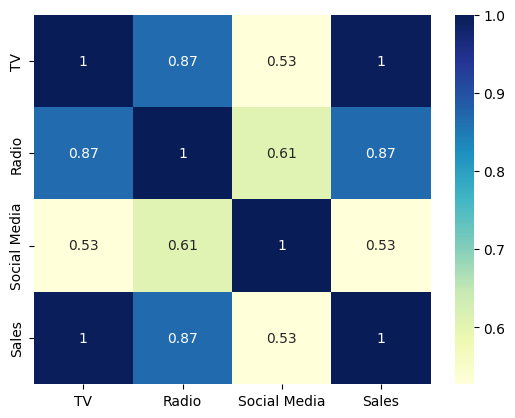

In [63]:
import matplotlib.pyplot as plt
import seaborn as sns

new_df = df[['TV', 'Radio', 'Social Media', 'Sales']]
sns.heatmap(new_df.corr(numeric_only=True), cmap="YlGnBu", annot=True)
plt.show()

In [64]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 4572 entries, 0 to 4571
Data columns (total 8 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   TV                4572 non-null   float64
 1   Radio             4572 non-null   float64
 2   Social Media      4572 non-null   float64
 3   Sales             4572 non-null   float64
 4   Influencer_Macro  4572 non-null   bool   
 5   Influencer_Mega   4572 non-null   bool   
 6   Influencer_Micro  4572 non-null   bool   
 7   Influencer_Nano   4572 non-null   bool   
dtypes: bool(4), float64(4)
memory usage: 160.9 KB


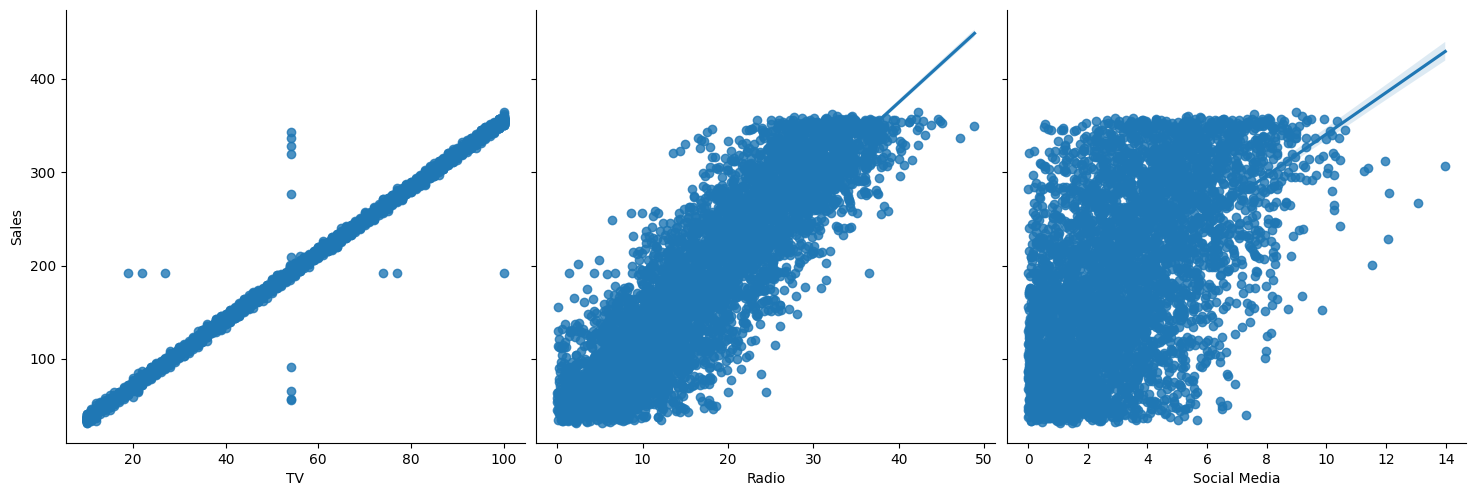

In [67]:
sns.pairplot(data = df,
             x_vars = ['TV', 'Radio', 'Social Media'],
             y_vars = 'Sales',
             height = 5,
             kind = 'reg')
plt.show()

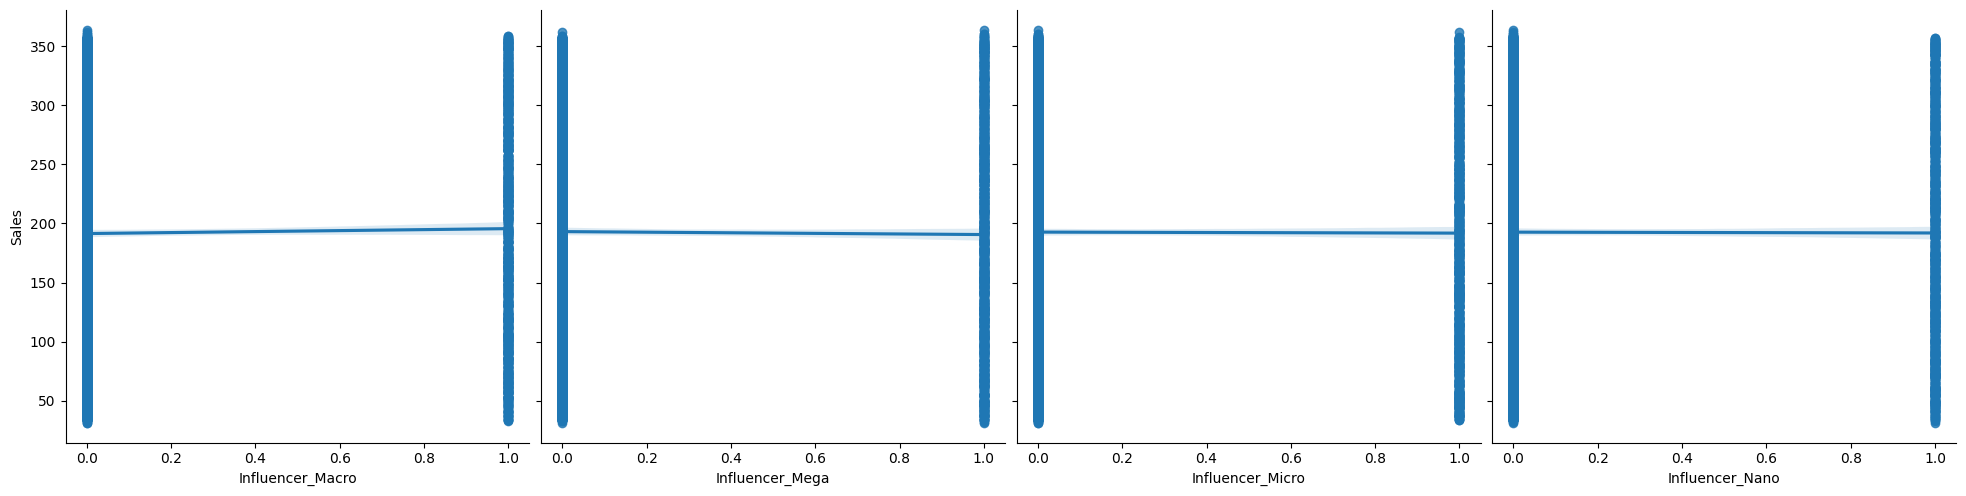

In [66]:
sns.pairplot(data = df,
             x_vars = ['Influencer_Macro', 'Influencer_Mega', 'Influencer_Micro', 'Influencer_Nano'],
             y_vars = 'Sales',
             height = 5,
             kind = 'reg')
plt.show()

# **Get data and split data**

In [69]:
df.columns

Index(['TV', 'Radio', 'Social Media', 'Sales', 'Influencer_Macro',
       'Influencer_Mega', 'Influencer_Micro', 'Influencer_Nano'],
      dtype='object')

In [82]:
X = df[['TV', 'Radio', 'Social Media', 'Influencer_Mega', 'Influencer_Micro', 'Influencer_Nano']]
df

,TV,Radio,Social Media,Sales,Influencer_Macro,Influencer_Mega,Influencer_Micro,Influencer_Nano
0,16.0,6.566231,2.907983,54.732757,False,True,False,False
1,13.0,9.237765,2.409567,46.677897,False,True,False,False
2,41.0,15.886446,2.913410,150.177829,False,True,False,False
3,83.0,30.020028,6.922304,298.246340,False,True,False,False
4,15.0,8.437408,1.405998,56.594181,False,False,True,False
...,...,...,...,...,...,...,...,...
4567,26.0,4.472360,0.717090,94.685866,False,False,True,False
4568,71.0,20.610685,6.545573,249.101915,False,False,False,True
4569,44.0,19.800072,5.096192,163.631457,False,False,True,False
4570,71.0,17.534640,1.940873,253.610411,True,False,False,False


In [83]:
y = df[['Sales']]
y

,Sales
0,54.732757
1,46.677897
2,150.177829
3,298.246340
4,56.594181
...,...
4567,94.685866
4568,249.101915
4569,163.631457
4570,253.610411


In [84]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.33, random_state=0)

In [85]:
X_train.shape, y_train.shape

((3063, 6), (3063, 1))

In [86]:
X_test.shape, y_test.shape

((1509, 6), (1509, 1))

# **Normalization**

In [87]:
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()

X_train_processed = scaler.fit_transform(X_train)
X_test_processed = scaler.fit_transform(X_test)

In [88]:
scaler.mean_

array([53.85023194, 18.02301178,  3.29739539,  0.25712392,  0.25646123,
        0.24585818])

In [89]:
scaler.scale_

array([26.15983081,  9.7581235 ,  2.19710685,  0.43704829,  0.43667937,
        0.43059486])

In [90]:
X_train_processed

array([[ 0.33869282, -0.3935435 , -0.17228084, -0.57948652,  1.73167391,
        -0.57848122],
       [-0.19852366, -0.28899849, -1.47661593,  1.72566569, -0.57747593,
        -0.57848122],
       [-0.42875929, -1.07436552, -0.55865556, -0.57948652, -0.57747593,
         1.72866459],
       ...,
       [-1.61831007, -1.72922605,  0.58649299, -0.57948652, -0.57747593,
         1.72866459],
       [-0.58224971, -0.91383556, -1.22645549, -0.57948652,  1.73167391,
        -0.57848122],
       [-1.27295662, -1.45779228, -1.04859981, -0.57948652,  1.73167391,
        -0.57848122]])

In [91]:
X_test_processed

array([[-0.33831381, -0.09176884, -0.8349793 , -0.58831925,  1.70271102,
        -0.57097333],
       [ 0.77025605,  1.17821405, -0.43886714, -0.58831925, -0.58729872,
         1.75139529],
       [ 1.15252152,  1.04864751,  1.09352839,  1.69975741, -0.58729872,
        -0.57097333],
       ...,
       [ 0.96138879,  1.12388703,  1.09651853,  1.69975741, -0.58729872,
        -0.57097333],
       [-0.4147669 , -0.29991669,  1.2298153 ,  1.69975741, -0.58729872,
        -0.57097333],
       [-0.91171201, -1.21956787, -0.31431739,  1.69975741, -0.58729872,
        -0.57097333]])

# **Custom Regression**

In [92]:
class CustomLinearRegression:
    def __init__(self, X_data, y_target, learning_rate=0.01, num_epochs=10000):
        self.num_samples = X_data.shape[0]
        self.X_data = np.c_[np.ones((self.num_samples, 1)), X_data]
        self.y_target = y_target
        self.learning_rate = learning_rate
        self.num_epochs = num_epochs
        self.num_features = self.X_data.shape[1]

        # Initial weights
        self.theta = np.random.randn(self.X_data.shape[1], 1)
        self.losses = []

    def compute_loss(self, y_pred, y_target):
        loss = (y_pred - y_target)**2
        loss = np.mean(loss)
        return loss

    def predict(self, X_data):
        if X_data.shape[1] == self.num_features:
            y_pred = X_data.dot(self.theta)
        else:
            X_data = np.c_[np.ones((X_data.shape[0], 1)), X_data]
            y_pred = X_data.dot(self.theta)
        return y_pred

    def fit(self):
        for epoch in range(self.num_epochs):
            # predict
            y_pred = self.predict(self.X_data)

            # compute loss
            loss = self.compute_loss(y_pred, self.y_target)
            self.losses.append(loss)

            # compute gradient
            loss_grd = 2*(y_pred - self.y_target)/self.num_samples
            gradients = self.X_data.T.dot(loss_grd)

            # update weight
            self.theta = self.theta - self.learning_rate*gradients

            if (epoch % 50) == 0:
                print(f'Epoch: {epoch} - Loss: {loss}')

        return {
            'loss': sum(self.losses)/len(self.losses),
            'weight': self.theta
        }

In [98]:
linear_model = CustomLinearRegression(X_train_processed, y_train, learning_rate=0.01, num_epochs=1000)
linear_model.fit()

Epoch: 0 - Loss: 46559.014792658636
Epoch: 50 - Loss: 5822.596716462375
Epoch: 100 - Loss: 1114.0535563292176
Epoch: 150 - Loss: 401.2549517288626
Epoch: 200 - Loss: 252.24423338804218
Epoch: 250 - Loss: 197.0378059508769
Epoch: 300 - Loss: 164.61982008378698
Epoch: 350 - Loss: 141.68319401004797
Epoch: 400 - Loss: 124.464973900618
Epoch: 450 - Loss: 111.27452638294636
Epoch: 500 - Loss: 101.0890607752803
Epoch: 550 - Loss: 93.1973370906393
Epoch: 600 - Loss: 87.07364142410825
Epoch: 650 - Loss: 82.31866948972487
Epoch: 700 - Loss: 78.62536876232855
Epoch: 750 - Loss: 75.75629723805268
Epoch: 800 - Loss: 73.5273730852108
Epoch: 850 - Loss: 71.79571736092477
Epoch: 900 - Loss: 70.45037313501763
Epoch: 950 - Loss: 69.40515285156847


{'loss': np.float64(1233.625826960434),
 'weight': array([[ 1.92950605e+02],
        [ 8.79656918e+01],
        [ 5.28536159e+00],
        [-3.91850853e-01],
        [ 1.42966103e-01],
        [ 9.87690377e-02],
        [ 1.72155539e-01]])}

In [102]:
y_pred_test = linear_model.predict(X_test_processed)
y_pred_train = linear_model.predict(X_train_processed)

In [104]:
from sklearn.metrics import r2_score

print("R2-Score in test: ", r2_score(y_test, y_pred_test))
print("R2-Score in train: ", r2_score(y_train, y_pred_train))

R2-Score in test:  0.994380760820253
R2-Score in train:  0.9920832061426925


# **Linear Regression in Sklearn**

In [105]:
from sklearn.linear_model import LinearRegression

linear_model = LinearRegression()
linear_model.fit(X_train_processed, y_train)

LinearRegression()

In [106]:
y_pred_test = linear_model.predict(X_test_processed)
y_pred_train = linear_model.predict(X_train_processed)

In [107]:
from sklearn.metrics import r2_score

print("R2-Score in test: ", r2_score(y_test, y_pred_test))
print("R2-Score in train: ", r2_score(y_train, y_pred_train))

R2-Score in test:  0.9950414024634753
R2-Score in train:  0.9924096197743346


# **Polynomial Regression**

In [109]:
X = df[['TV', 'Radio', 'Social Media', 'Influencer_Mega', 'Influencer_Micro', 'Influencer_Nano']]
y = df[['Sales']]

In [111]:
from sklearn.preprocessing import PolynomialFeatures

poly = PolynomialFeatures(degree=2)
X_poly = poly.fit_transform(X)

In [113]:
X_poly.shape

(4572, 28)

In [114]:
X_train, X_test, y_train, y_test = train_test_split(X_poly, y, test_size=0.33, random_state=42)

In [116]:
scaler = StandardScaler()
X_train_processed = scaler.fit_transform(X_train)
X_test_processed = scaler.fit_transform(X_test)

In [118]:
X_train_processed.shape, X_test_processed.shape

((3063, 28), (1509, 28))

In [119]:
from sklearn.linear_model import LinearRegression

linear_model = LinearRegression()
linear_model.fit(X_train_processed, y_train)

LinearRegression()

In [120]:
y_pred_test = linear_model.predict(X_test_processed)
y_pred_train = linear_model.predict(X_train_processed)

In [121]:
from sklearn.metrics import r2_score

print("R2-Score in test: ", r2_score(y_test, y_pred_test))
print("R2-Score in train: ", r2_score(y_train, y_pred_train))

R2-Score in test:  0.9898731448904636
R2-Score in train:  0.9945289104697999


In [122]:
linear_model = CustomLinearRegression(X_train_processed, y_train, learning_rate=0.01, num_epochs=1000)
linear_model.fit()

Epoch: 0 - Loss: 46169.31208556272
Epoch: 50 - Loss: 5433.230081857891
Epoch: 100 - Loss: 958.3041242080056
Epoch: 150 - Loss: 312.29011814538984
Epoch: 200 - Loss: 193.01496299790037
Epoch: 250 - Loss: 156.45410831370864
Epoch: 300 - Loss: 138.22468676950808
Epoch: 350 - Loss: 126.6597760954865
Epoch: 400 - Loss: 118.48149248825824
Epoch: 450 - Loss: 112.29031032303085
Epoch: 500 - Loss: 107.35393481359618
Epoch: 550 - Loss: 103.25813334707594
Epoch: 600 - Loss: 99.75809520302693
Epoch: 650 - Loss: 96.70298359709744
Epoch: 700 - Loss: 93.99540757663628
Epoch: 750 - Loss: 91.5691959509529
Epoch: 800 - Loss: 89.377034895329
Epoch: 850 - Loss: 87.3834782551133
Epoch: 900 - Loss: 85.56090782022991
Epoch: 950 - Loss: 83.88712936010371


{'loss': np.float64(1139.9198712180703),
 'weight': array([[ 1.93469053e+02],
        [ 2.23709515e-01],
        [ 5.63832115e+01],
        [ 1.25083445e+01],
        [ 2.32246481e+00],
        [-9.03626639e-01],
        [-1.24413850e+00],
        [-2.60629358e+00],
        [ 2.53430090e+01],
        [ 4.88268194e+00],
        [ 4.38999203e+00],
        [ 6.03860658e+00],
        [ 7.05327080e+00],
        [ 8.13616446e+00],
        [-9.85102573e+00],
        [-4.93238934e+00],
        [-1.24351525e+00],
        [-1.91789178e+00],
        [-3.43389930e+00],
        [-7.16510085e-01],
        [-1.60253228e+00],
        [-1.28695747e+00],
        [-1.52256943e+00],
        [-1.94739836e+00],
        [-1.05487231e+00],
        [ 9.77078452e-01],
        [-2.36662144e+00],
        [-4.45134660e-02],
        [-5.33437018e-01]])}

In [123]:
y_pred_test = linear_model.predict(X_test_processed)
y_pred_train = linear_model.predict(X_train_processed)

In [124]:
from sklearn.metrics import r2_score

print("R2-Score in test: ", r2_score(y_test, y_pred_test))
print("R2-Score in train: ", r2_score(y_train, y_pred_train))

R2-Score in test:  0.9867210496931497
R2-Score in train:  0.9905032599382225


# **Linear with 'TV', 'Radio' and Polynomial with 'Social Media'**

In [125]:
X = df[['TV', 'Radio', 'Social Media']]
y = df[['Sales']]

In [126]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.33, random_state=0)

In [143]:
from sklearn.preprocessing import PolynomialFeatures
import numpy as np

poly = PolynomialFeatures(degree=2)
sm_poly_train = poly.fit_transform(X_train[["Social Media"]])
sm_poly_test = poly.transform(X_test[["Social Media"]])

In [145]:
X_train_final = np.hstack([X_train[["TV", "Radio"]].values, sm_poly_train])
X_test_final = np.hstack([X_test[["TV", "Radio"]].values, sm_poly_test])

In [147]:
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train_final)
X_test_scaled = scaler.transform(X_test_final)

In [148]:
from sklearn.linear_model import LinearRegression

model = LinearRegression()
model.fit(X_train_scaled, y_train)

LinearRegression()

In [149]:
y_pred_train = model.predict(X_train_scaled)
y_pred_test = model.predict(X_test_scaled)

print(f"R2-Score (Train): {r2_score(y_train, y_pred_train):.5f}")
print(f"R2-Score (Test) : {r2_score(y_test, y_pred_test):.5f}")

R2-Score (Train): 0.99240
R2-Score (Test) : 0.99527
